In [1]:
import pyarrow.parquet as pq
import pyarrow.compute as pc


In [2]:
data_path = "/scratch/work/masooda1/mocop/data/jump_data/cell_fetures_with_smiles_1000.parquet"
smiles_col = "Metadata_SMILES"

morph_dataset = pq.ParquetDataset(data_path)

In [11]:
morph_smiles = pq.read_table(data_path, columns=[smiles_col]).to_pandas()

cell_smiles = list(set(morph_smiles.dropna()[smiles_col].unique()))
morph_schema = morph_dataset.schema
       
morph_cols = [field.name for field in morph_schema 
              if not field.name.startswith("Metadata_")]

In [12]:
smiles = cell_smiles[0]
morph_table = morph_dataset.read(columns=morph_cols + [smiles_col])
morph_filtered = morph_table.filter(pc.field(smiles_col) == smiles)
# Reset index when converting to pandas to avoid index-related issues
morph_data = morph_filtered.to_pandas().reset_index(drop=True).drop("Metadata_SMILES", axis = 1)
    
morph_feat = (morph_data
                    .sample(1)
                    .values
                    .astype(float)
                    .flatten()
                )
print(morph_feat.shape, smiles)

(3479,) CCC(C)c1cc(C(=O)N2CCS(=O)(=O)CC2c2cnn(CC)c2)on1


In [23]:
morph_feat.nbytes / 1024

27.1796875

In [11]:
morph_feat

array([-0.33792573,  1.10036862, -0.33501607, ...,  0.49666518,
        0.32292038,  0.26192093])

In [1]:
import sys 
sys.path.insert(1, '/scratch/work/masooda1/mocop')
from mocop import model
from mocop import dataset
from mocop.training import build_dataloaders
import pandas as pd
import pyarrow.parquet as pq

In [2]:
encoder_a = model.GatedGraphNeuralNetwork(
                                    n_edge = 1,
                                    in_dim = 75,
                                    n_conv = 6,
                                    fc_dims = [1024],
                                    p_dropout = 0.1)

In [3]:
encoder_b = model.MultiLayerPerceptron(
                                num_input_features=3475, 
                                hidden_layer_dimensions = [512,256,128],
                                p_dropout =  0.1)

In [4]:
dual_modal = model.DualInputEncoder(
                            encoder_a = encoder_a,
                            encoder_b = encoder_b,
                            supervised_head_dim = [202],
                            non_lin_proj = True,
                            dim = 128,
                            temperature = 10)

In [5]:
#data_path = "/scratch/work/masooda1/datasets/mocop/centered.filtered.parquet"
data_path = "/scratch/work/masooda1/datasets/mocop/source_1.Batch1_20221004.UL001641.UL001641.centered.parquet"
ds = dataset.DualInputGraphDatasetJUMP(
                                data_path = data_path, 
                                pad_length = 250)

In [6]:
train = "/scratch/work/masooda1/mocop/data/jump/jump-compound-split-1-train.csv"
val = "/scratch/work/masooda1/mocop/data/jump/jump-compound-split-1-val.csv"
test = "/scratch/work/masooda1/mocop/data/jump/jump-compound-split-1-test.csv"

splits = dataset._split_data(dataset = ds, 
                    splits = {"train": train, "val": val, "test":test}) 

Split train: /scratch/work/masooda1/mocop/data/jump/jump-compound-split-1-train.csv
Split val: /scratch/work/masooda1/mocop/data/jump/jump-compound-split-1-val.csv
Split test: /scratch/work/masooda1/mocop/data/jump/jump-compound-split-1-test.csv


In [10]:
len(splits["train"])

3

In [ ]:
dl = build_dataloaders(
                dataset = ds,
                batch_size = 1,
                num_workers = 1,
                splits = {"train": train, "val": val, "test":test})

In [ ]:
example

In [2]:
import sys 
sys.path.insert(1, '/scratch/work/masooda1/mocop')
from mocop import model

from featurizer.molgraph_rdkit import MolGraph
from featurizer.smiles_transformation import smiles2fp, smiles2graph

In [3]:
smiles = "CC(=O)OC1=CC=CC=C1C(=O)O"  # Aspirin
adj_mat, node_feat = smiles2graph(smiles)

In [4]:
adj_mat.shape, node_feat.shape

((13, 13), (13, 75))

In [6]:
FP = smiles2fp(smiles)

In [ ]:
# read JUMP CP dataset
data_path = "/scratch/work/masooda1/datasets/mocop/centered.filtered.parquet"
df = pd.read_parquet(data_path, engine='pyarrow')

In [4]:
data_path = "/scratch/work/masooda1/datasets/mocop/centered.filtered.parquet"

# Get metadata and schema
parquet_file = pq.ParquetFile(data_path)
#print(parquet_file.metadata)
#print(parquet_file.schema)


In [1]:
from memory_profiler import memory_usage

In [11]:
df

,Metadata_JCP2022,Metadata_Source,Metadata_Plate,Metadata_Well
0,JCP2022_000107,source_3,J12459b,A06
1,JCP2022_000650,source_3,J12459b,B12
2,JCP2022_000840,source_3,J12459b,F12
3,JCP2022_000849,source_3,J12459b,P19
4,JCP2022_001460,source_3,J12459b,D10
...,...,...,...,...
1467,JCP2022_116281,source_1,UL000087,J19
1468,JCP2022_116581,source_1,UL000087,X23
1469,JCP2022_116597,source_1,UL000087,I29
1470,JCP2022_116638,source_1,UL000087,C27


In [4]:
import pandas as pd
import numpy as np
from mocop.dataset import _split_data


In [5]:
from typing import Dict

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, Subset

from featurizer.smiles_transformation import (inchi2smiles, smiles2fp,
                                              smiles2graph)


class SupervisedGraphDataset(Dataset):
    def __init__(
        self, data_path, cmpd_col="smiles", cmpd_col_is_inchikey=False, pad_length=0
    ):
        if "parquet" in data_path:
            self.df = pd.read_parquet(data_path)
        else:
            self.df = pd.read_csv(data_path)

        self.df = self.df.set_index(cmpd_col)
        if cmpd_col_is_inchikey:
            self.df.index = [inchi2smiles(s) for s in self.df.index]
        self.df = self.df[[c for c in self.df.columns if not c.startswith("Metadata")]]
        self.unique_smiles = self.df.index
        self.pad_length = pad_length

    def __len__(self):
        return len(self.unique_smiles)

    def _pad(self, adj_mat, node_feat, atom_vec):
        p = self.pad_length - len(atom_vec)
        if p >= 0:
            adj_mat = F.pad(adj_mat, (0, p, 0, p), "constant", 0)
            node_feat = F.pad(node_feat, (0, 0, 0, p), "constant", 0)
            atom_vec = F.pad(atom_vec, (0, 0, 0, p), "constant", 0)
        return adj_mat, node_feat, atom_vec

    def __getitem__(self, index):
        smiles = self.unique_smiles[index]
        adj_mat, node_feat = smiles2graph(smiles)
        adj_mat = torch.FloatTensor(adj_mat)
        node_feat = torch.FloatTensor(node_feat)
        atom_vec = torch.ones(len(node_feat), 1)
        cmpd_feat = self._pad(adj_mat, node_feat, atom_vec)

        labels = self.df.loc[smiles]

        if len(labels.shape) > 1 and len(labels) > 1:
            labels = labels.sample(1).iloc[0]

        labels = torch.FloatTensor(labels.values)
        return {
            "inputs": {"x_a": [torch.FloatTensor(f) for f in cmpd_feat]},
            "labels": labels,
        }


In [12]:
import pandas as pd

df = pd.read_csv('/scratch/work/masooda1/mocop/data/chembl20/chembl20.csv')
df.to_parquet('/scratch/work/masooda1/mocop/data/chembl20/chembl20.parquet')

In [13]:
import pandas as pd

def extract_train_set(main_file, split_file):
    # Read the main parquet file
    main_df = pd.read_parquet(main_file)
    
    # Read the split file
    split_df = pd.read_csv(split_file)
    
    # Extract the indices for the train set
    train_indices = split_df['index'].values
    
    # Use these indices to get the train set from the main dataframe
    train_set = main_df.iloc[train_indices]
    
    return train_set

In [14]:
# Use the function
train_data = extract_train_set('/scratch/work/masooda1/mocop/data/chembl20/chembl20.parquet',
                               '/scratch/work/masooda1/mocop/data/chembl20/chembl20-frac1-split1-train.csv')

In [15]:
train_data

,smiles,0,1,2,3,4,5,6,7,8,...,1300,1301,1302,1303,1304,1305,1306,1307,1308,1309
131031,COc1cc(C2OCC3C(c4cc(OC)c(OC)c(OC)c4)OCC23)cc(O...,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
268703,CN(C(=O)Cn1nnc(-c2ccc(S(C)(=O)=O)cc2)n1)c1ccccc1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
360170,O=C(COc1ccc(Br)cc1)OCC(=O)c1ccc[nH]1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
7385,Oc1cc(-c2c[nH]c3ccccc23)nc2cc3c(cc12)OCO3,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
115340,Cl.N=c1sccn1CC(=O)Nc1ccccc1Oc1ccccc1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419233,CCOC(=O)N1CCN(C(=O)CC2CC3(C(=O)OC)CCCCC=C3N(Cc...,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
231547,CC1CCN(C(=O)CN(c2ccc3c(c2)OCCO3)S(=O)(=O)c2ccc...,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
124803,COc1ccc(C=CC2=NNC(=O)CC2)cc1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
192352,Cc1cccc(NC(=S)NC(=O)C=Cc2ccccc2)n1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [4]:
# Load TensorBoard extension
%load_ext tensorboard

# Specify the directory containing your TensorFlow event logs
log_dir = '/scratch/work/masooda1/trained_model_pred/mocop/chembl20_fromscratch_frac_1_split_1_seed_0/version_1'  # Replace with the actual path to your event logs

# Start TensorBoard from within Jupyter
%tensorboard --logdir {log_dir}


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 1388061), started 0:00:47 ago. (Use '!kill 1388061' to kill it.)

In [5]:
pip install wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 91.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import wandb

In [4]:
wandb.login(key = "27edf9c66b032c03f72d30e923276b93aa736429")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/masooda1/.netrc


True

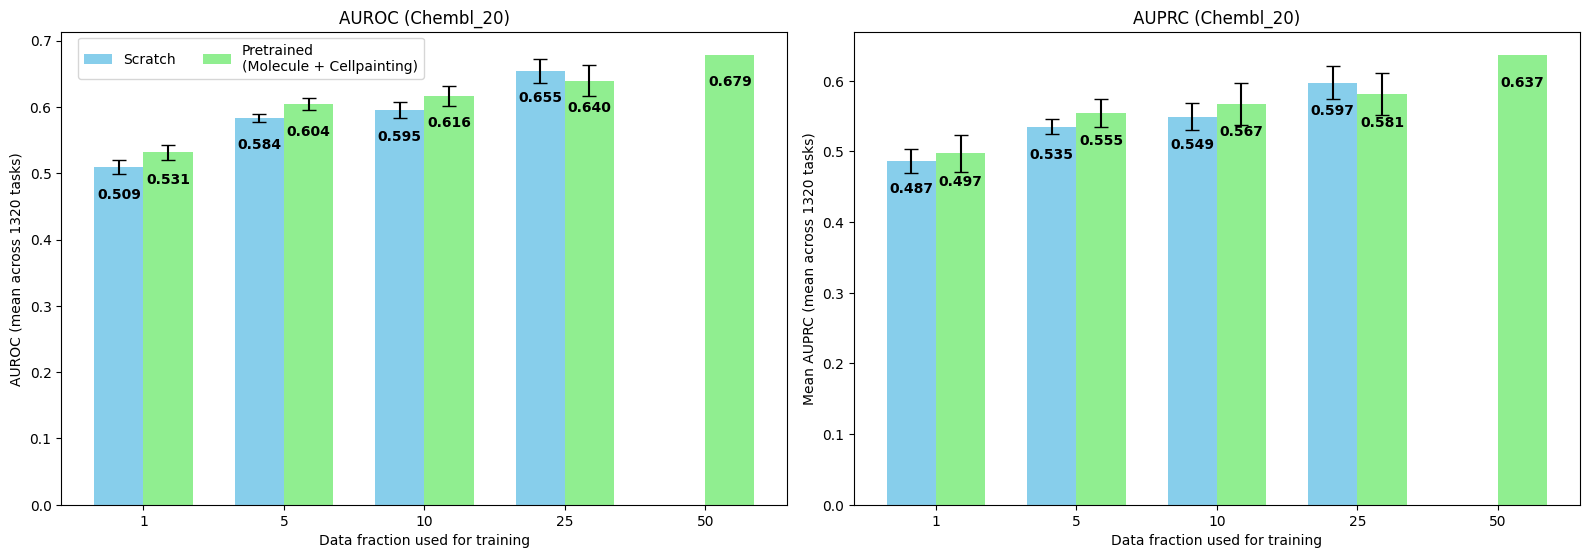

In [6]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

def load_data(results_dir, model_name):
    all_data = []
    pattern = r"frac(\d+)_split(\d+)_seed(\d+)\.json"
    
    for filename in os.listdir(results_dir):
        if filename.endswith(".json"):
            match = re.match(pattern, filename)
            if match:
                frac, split, seed = match.groups()
                with open(os.path.join(results_dir, filename), 'r') as f:
                    data = json.load(f)
                new_data = {
                    'frac': int(frac),
                    'split': int(split),
                    'seed': int(seed),
                    'model': model_name
                }
                new_data.update(data)
                all_data.append(new_data)
    
    return pd.DataFrame(all_data)

# Load data for both models
df1 = load_data("/scratch/work/masooda1/trained_model_pred/mocop/test_results/chembl_20_from_scratch", "Scratch")
df2 = load_data("/scratch/work/masooda1/trained_model_pred/chembl_20_mocop_linear_prob/test_results/chembl20_mocop_linear", "Pretrained\n(Molecule + Cellpainting)")

# Combine the data
df = pd.concat([df1, df2])

# Calculate mean values and standard deviations
mean_values = df.groupby(['frac', 'model'])[['val/auroc_mean', 'val/auprc_mean']].mean().reset_index()
std_values = df.groupby(['frac', 'model'])[['val/auroc_mean', 'val/auprc_mean']].std().reset_index()

# Set up the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Define the order of models and their colors
model_order = ["Scratch", "Pretrained\n(Molecule + Cellpainting)"]
colors = ["skyblue", "lightgreen"]

# Function to plot bars and add text
def plot_bars(ax, data, y_col, title, ylabel):
    fracs = sorted(data['frac'].unique())
    x = np.arange(len(fracs))
    width = 0.35
    
    for i, (model, color) in enumerate(zip(model_order, colors)):
        model_data = data[data['model'] == model]
        means = [model_data[model_data['frac'] == frac][y_col].values[0] if frac in model_data['frac'].values else np.nan for frac in fracs]
        stds = [std_values[(std_values['frac'] == frac) & (std_values['model'] == model)][y_col].values[0] if frac in model_data['frac'].values else np.nan for frac in fracs]
        
        bars = ax.bar(x + (i-0.5)*width, means, width, label=model, yerr=stds, capsize=5, color=color)
        
        for j, (mean, std) in enumerate(zip(means, stds)):
            if not np.isnan(mean):
                ax.text(x[j] + (i-0.5)*width, mean - 0.03, f'{mean:.3f}', ha='center', va='top', fontweight='bold')  # Adjusted position

    ax.set_title(title)
    ax.set_xlabel('Data fraction used for training')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(fracs)

# Plot AUROC
plot_bars(ax1, mean_values, 'val/auroc_mean', 'AUROC (Chembl_20)', 'AUROC (mean across 1320 tasks)')

# Plot AUPRC
plot_bars(ax2, mean_values, 'val/auprc_mean', 'AUPRC (Chembl_20)', 'Mean AUPRC (mean across 1320 tasks)')

# Add a single legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.16, 0.94), ncol=2)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Adjust this value to make room for the legend
plt.show()

# Optionally, save the plot
fig.savefig('/scratch/work/masooda1/Results/Multimodal/mocop/Chembl_20_from_scratch_vs_pretrained_2_modalities.png', dpi=300, bbox_inches='tight')

In [53]:
df.columns

Index(['frac', 'split', 'seed', 'model', 'val/auroc_mean', 'val/auprc_mean',
       'val/auroc_0', 'val/auroc_1', 'val/auroc_2', 'val/auroc_3',
       ...
       'val/auprc_1302', 'val/auprc_1303', 'val/auprc_1304', 'val/auprc_1305',
       'val/auprc_1306', 'val/auprc_1307', 'val/auprc_1308', 'val/auprc_1309',
       'val/supervised_loss', 'val/loss'],
      dtype='object', length=2628)

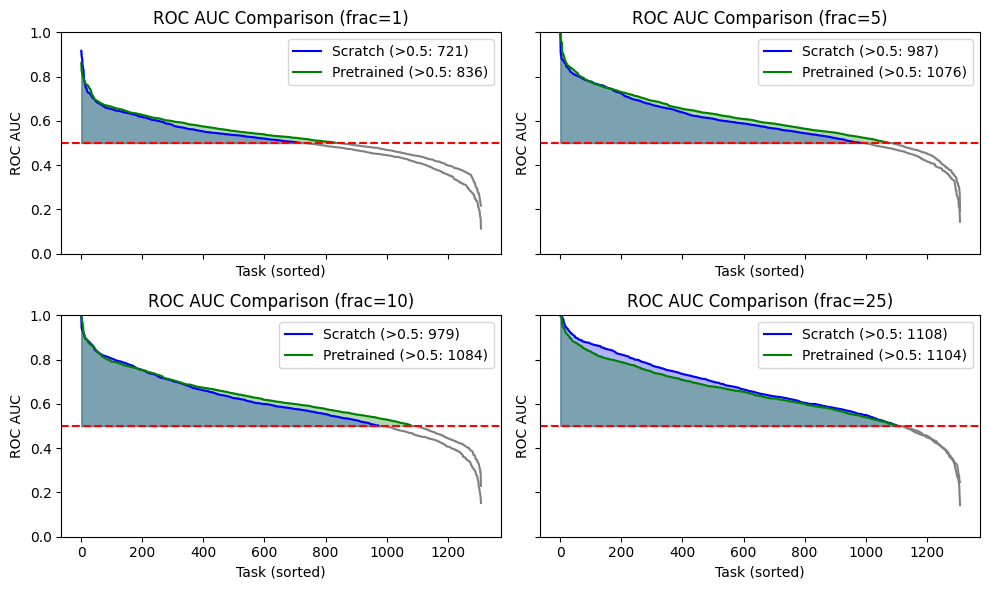

In [7]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

def load_data(results_dir, model_name):
    all_data = []
    pattern = r"frac(\d+)_split(\d+)_seed(\d+)\.json"
    
    for filename in os.listdir(results_dir):
        if filename.endswith(".json"):
            match = re.match(pattern, filename)
            if match:
                frac, split, seed = match.groups()
                with open(os.path.join(results_dir, filename), 'r') as f:
                    data = json.load(f)
                new_data = {
                    'frac': int(frac),
                    'split': int(split),
                    'seed': int(seed),
                    'model': model_name
                }
                new_data.update(data)
                all_data.append(new_data)
    
    return pd.DataFrame(all_data)

# Load data for both models
df_model1 = load_data("/scratch/work/masooda1/trained_model_pred/mocop/test_results/chembl_20_from_scratch", "Scratch")
df_model2 = load_data("/scratch/work/masooda1/trained_model_pred/chembl_20_mocop_linear_prob/test_results/chembl20_mocop_linear", "Pretrained")

# Extract AUROC columns
auroc_columns = [f'val/auroc_{i}' for i in range(1310)]

# Get unique fractions
fractions = sorted(df_model1['frac'].unique())

# Calculate number of rows needed
n_rows = (len(fractions) + 1) // 2  # This will give us ceiling division

# Create subplots
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 3*n_rows), sharey = True, sharex = True)

for idx, frac in enumerate(fractions):
    # Calculate row and column index
    row = idx // 2
    col = idx % 2
    
    # Filter data for current fraction
    df_model1_frac = df_model1[df_model1['frac'] == frac]
    df_model2_frac = df_model2[df_model2['frac'] == frac]
    
    # Calculate mean across splits and seeds for each task
    mean_auroc_model1 = df_model1_frac[auroc_columns].mean()
    mean_auroc_model2 = df_model2_frac[auroc_columns].mean()
    
    # Sort the values
    sorted_auroc_model1 = mean_auroc_model1.sort_values(ascending=False)
    sorted_auroc_model2 = mean_auroc_model2.sort_values(ascending=False)
    
    # Get the current axis
    ax = axes[row, col] if n_rows > 1 else axes[col]
    
    # Plot sorted lines for both models
    x = np.arange(1310)
    
    # Model 1
    mask1 = sorted_auroc_model1 > 0.5
    count1 = mask1.sum()
    ax.plot(x[mask1], sorted_auroc_model1[mask1], color='blue', label=f'Scratch (>{0.5}: {count1})')
    ax.plot(x[~mask1], sorted_auroc_model1[~mask1], color='gray')
    
    # Model 2
    mask2 = sorted_auroc_model2 > 0.5
    count2 = mask2.sum()
    ax.plot(x[mask2], sorted_auroc_model2[mask2], color='green', label=f'Pretrained (>{0.5}: {count2})')
    ax.plot(x[~mask2], sorted_auroc_model2[~mask2], color='gray')
    
    ax.set_title(f'ROC AUC Comparison (frac={frac})')
    ax.set_xlabel('Task (sorted)')
    ax.set_ylabel('ROC AUC')
    ax.set_ylim(0, 1)
    ax.legend()
    
    # Fill between the lines and x-axis
    ax.fill_between(x[mask1], sorted_auroc_model1[mask1], 0.5, alpha=0.3, color='blue')
    ax.fill_between(x[mask2], sorted_auroc_model2[mask2], 0.5, alpha=0.3, color='green')
    
    # Add a horizontal line at y=0.5
    ax.axhline(y=0.5, color='r', linestyle='--')

# Remove any unused subplots
if len(fractions) % 2 != 0:
    fig.delaxes(axes[n_rows-1, 1])

# Adjust layout
plt.tight_layout()
fig.savefig('/scratch/work/masooda1/Results/Multimodal/mocop/Chembl_20_from_scratch_vs_pretrained_2_modalities_ROC_AUC.png', dpi=300, bbox_inches='tight')
plt.show()

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
cell_fetures_with_smiles_2000 = pd.read_parquet("/scratch/work/masooda1/mocop/data/dummy_data/cell_fetures_with_smiles_2000.parquet")
cell_fetures_with_smiles_2000.Metadata_SMILES.nunique()

2000

In [3]:
genomic = pd.read_parquet("/scratch/work/masooda1/mocop/data/dummy_data/landmark_cmp_data_min1000compounds_all_measurements_test.parquet")
genomic.Metadata_SMILES.nunique()

2000

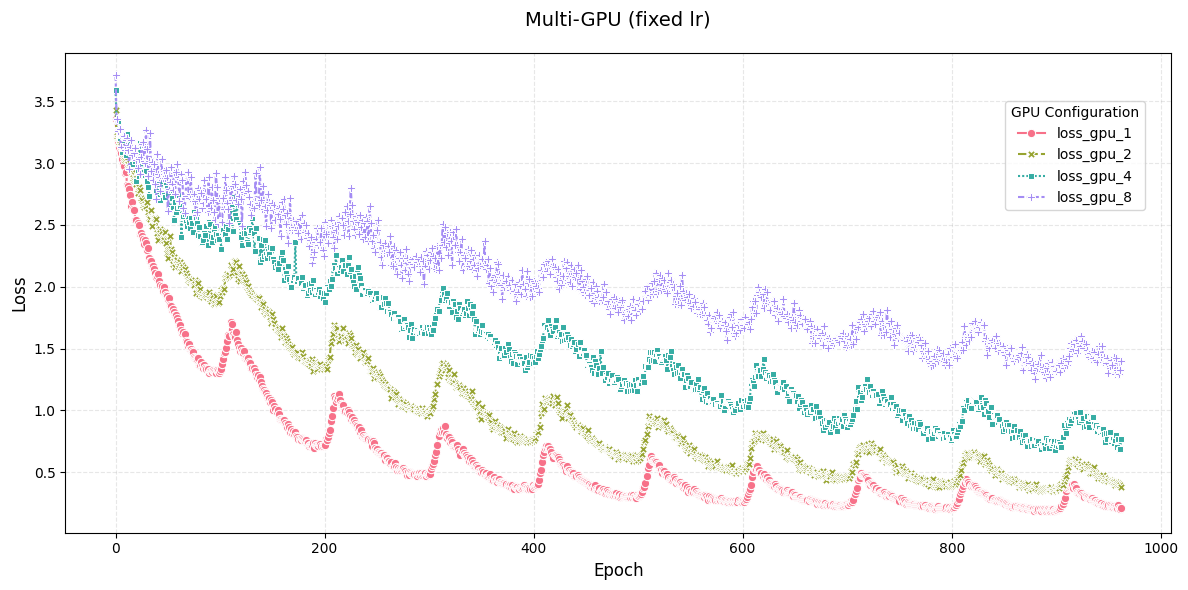

In [4]:
one_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-131__training_train_loss.csv").iloc[:,-1]
two_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-132__training_train_loss.csv").iloc[:,-1]
three_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-133__training_train_loss.csv").iloc[:,-1]
four_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-134__training_train_loss.csv").iloc[:,-1]

complete_data = pd.DataFrame({
            "loss_gpu_1":one_gpu,
            "loss_gpu_2":two_gpu,
            "loss_gpu_4":three_gpu,
            "loss_gpu_8":four_gpu})
complete_data.index = complete_data.index.set_names(['epoch'])
complete_data = complete_data.reset_index()
complete_data.dropna(inplace = True)

# Melt the dataframe for easier plotting
melted_data = complete_data.melt(id_vars=['epoch'], 
                                var_name='GPU Config', 
                                value_name='Loss')

# Create the plot
plt.figure(figsize=(12, 6))

# Create line plot with custom styling
sns.lineplot(data=melted_data,
            x='epoch',
            y='Loss',
            hue='GPU Config',
            style='GPU Config',  # Different line styles for each GPU
            markers=True,        # Add markers
            dashes=True,         # Use different dash patterns
            palette='husl')      # Color palette

# Customize the plot
plt.title('Multi-GPU (fixed lr)', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Format legend
plt.legend(title='GPU Configuration', 
          bbox_to_anchor=(0.85, 0.9), 
          loc='upper left',
          borderaxespad=0)

# Add grid
plt.grid(True, linestyle='--', alpha=0.3)

# Tight layout
plt.tight_layout()
plt.savefig('/scratch/work/masooda1/mocop/junk/Multi_GPU_Fix_LR.png', dpi=300, bbox_inches='tight')

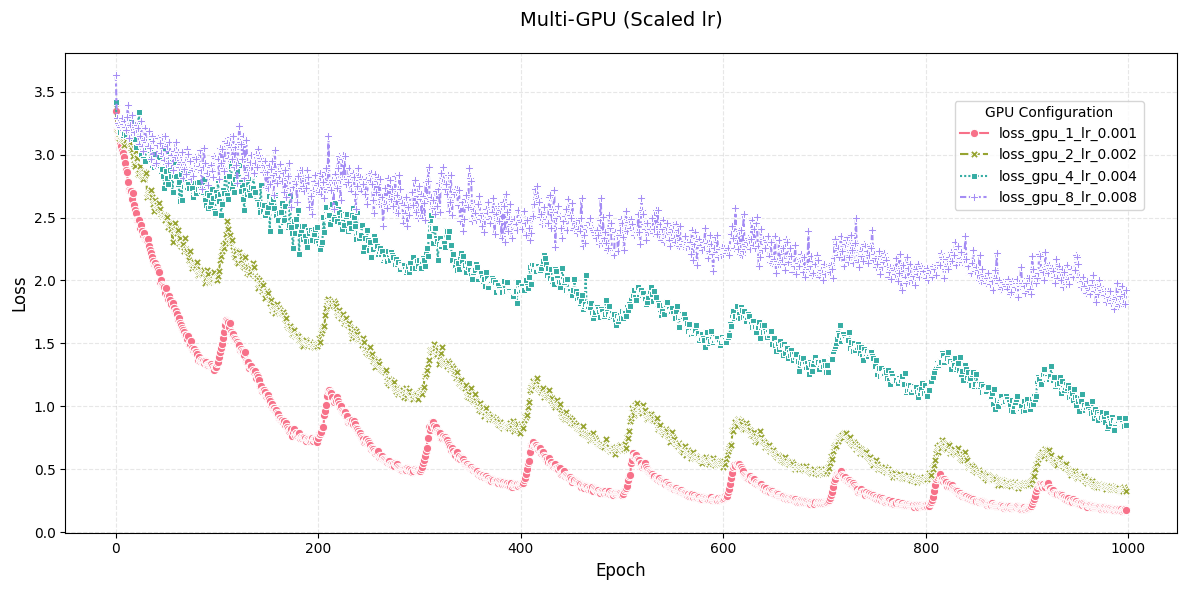

In [5]:
one_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-135__training_train_loss.csv").iloc[:,-1]
two_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-136__training_train_loss.csv").iloc[:,-1]
three_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-137__training_train_loss.csv").iloc[:,-1]
four_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-138__training_train_loss.csv").iloc[:,-1]

complete_data = pd.DataFrame({
            "loss_gpu_1_lr_0.001":one_gpu,
            "loss_gpu_2_lr_0.002":two_gpu,
            "loss_gpu_4_lr_0.004":three_gpu,
            "loss_gpu_8_lr_0.008":four_gpu})
complete_data.index = complete_data.index.set_names(['epoch'])
complete_data = complete_data.reset_index()
complete_data.dropna(inplace = True)

# Melt the dataframe for easier plotting
melted_data = complete_data.melt(id_vars=['epoch'], 
                                var_name='GPU Config', 
                                value_name='Loss')

# Create the plot
plt.figure(figsize=(12, 6))

# Create line plot with custom styling
sns.lineplot(data=melted_data,
            x='epoch',
            y='Loss',
            hue='GPU Config',
            style='GPU Config',  # Different line styles for each GPU
            markers=True,        # Add markers
            dashes=True,         # Use different dash patterns
            palette='husl')      # Color palette

# Customize the plot
plt.title('Multi-GPU (Scaled lr)', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Format legend
plt.legend(title='GPU Configuration', 
          bbox_to_anchor=(0.8, 0.9), 
          loc='upper left',
          borderaxespad=0)

# Add grid
plt.grid(True, linestyle='--', alpha=0.3)

# Tight layout
plt.tight_layout()


plt.savefig('/scratch/work/masooda1/mocop/junk/Multi_GPU_Scaled_LR.png', dpi=300, bbox_inches='tight')

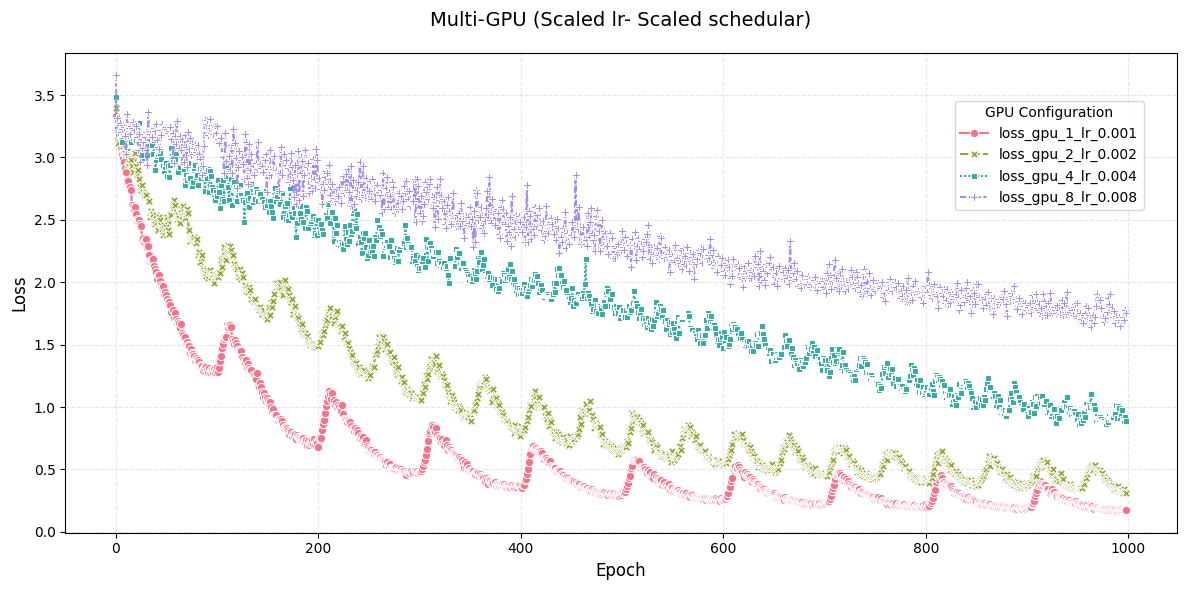

In [8]:
one_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-141__training_train_loss.csv").iloc[:,-1]
two_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-139__training_train_loss.csv").iloc[:,-1]
three_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-140__training_train_loss.csv").iloc[:,-1]
four_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-142__training_train_loss.csv").iloc[:,-1]

complete_data = pd.DataFrame({
            "loss_gpu_1_lr_0.001":one_gpu,
            "loss_gpu_2_lr_0.002":two_gpu,
            "loss_gpu_4_lr_0.004":three_gpu,
            "loss_gpu_8_lr_0.008":four_gpu})
complete_data.index = complete_data.index.set_names(['epoch'])
complete_data = complete_data.reset_index()
complete_data.dropna(inplace = True)

# Melt the dataframe for easier plotting
melted_data = complete_data.melt(id_vars=['epoch'], 
                                var_name='GPU Config', 
                                value_name='Loss')

# Create the plot
plt.figure(figsize=(12, 6))

# Create line plot with custom styling
sns.lineplot(data=melted_data,
            x='epoch',
            y='Loss',
            hue='GPU Config',
            style='GPU Config',  # Different line styles for each GPU
            markers=True,        # Add markers
            dashes=True,         # Use different dash patterns
            palette='husl')      # Color palette

# Customize the plot
plt.title('Multi-GPU (Scaled lr- Scaled schedular)', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Format legend
plt.legend(title='GPU Configuration', 
          bbox_to_anchor=(0.8, 0.9), 
          loc='upper left',
          borderaxespad=0)

# Add grid
plt.grid(True, linestyle='--', alpha=0.3)

# Tight layout
plt.tight_layout()


plt.savefig('/scratch/work/masooda1/mocop/junk/Multi_GPU_Scaled_LR_Scaled_schedular.png', dpi=300, bbox_inches='tight')

# Effect of batch size 

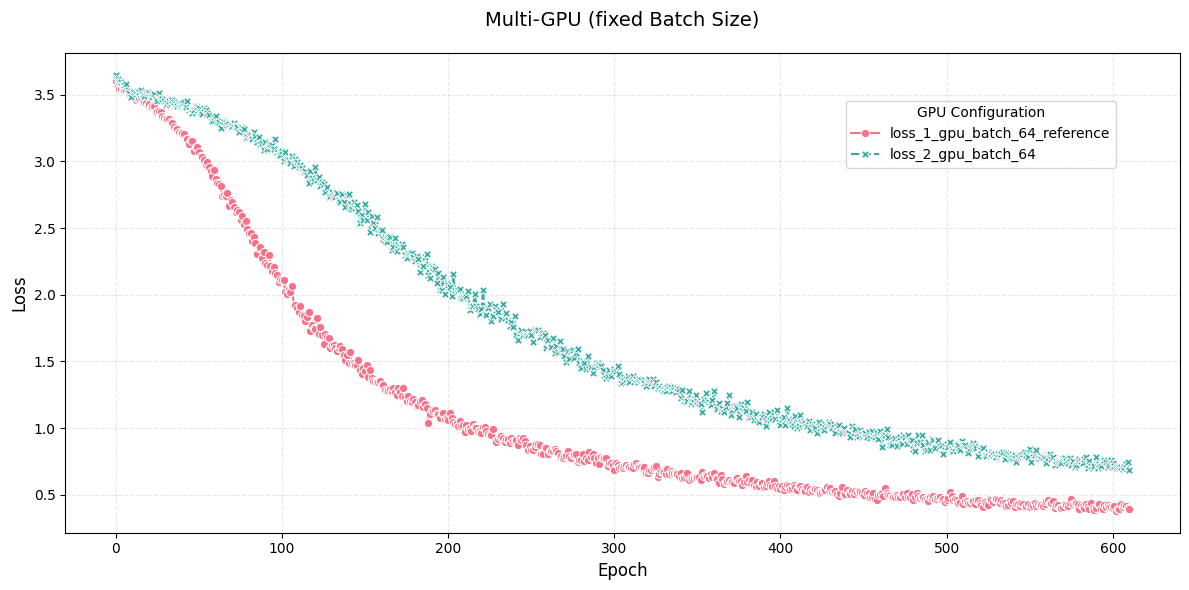

In [29]:
one_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/updated_exp/MOCOP1-149__training_train_morphological_loss.csv").iloc[:,-1]
two_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/updated_exp/MOCOP1-151__training_train_morphological_loss.csv").iloc[:,-1]
#three_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-140__training_train_loss.csv").iloc[:,-1]
#four_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-142__training_train_loss.csv").iloc[:,-1]

complete_data = pd.DataFrame({
            "loss_1_gpu_batch_64_reference":one_gpu,
            "loss_2_gpu_batch_64":two_gpu,
            #"loss_gpu_4_lr_0.004":three_gpu,
            #"loss_gpu_8_lr_0.008":four_gpu
            })
complete_data.index = complete_data.index.set_names(['epoch'])
complete_data = complete_data.reset_index()
complete_data.dropna(inplace = True)

# Melt the dataframe for easier plotting
melted_data = complete_data.melt(id_vars=['epoch'], 
                                var_name='GPU Config', 
                                value_name='Loss')

# Create the plot
plt.figure(figsize=(12, 6))

# Create line plot with custom styling
sns.lineplot(data=melted_data,
            x='epoch',
            y='Loss',
            hue='GPU Config',
            style='GPU Config',  # Different line styles for each GPU
            markers=True,        # Add markers
            dashes=True,         # Use different dash patterns
            palette='husl')      # Color palette

# Customize the plot
plt.title('Multi-GPU (fixed Batch Size)', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Format legend
plt.legend(title='GPU Configuration', 
          bbox_to_anchor=(0.7, 0.9), 
          loc='upper left',
          borderaxespad=0)

# Add grid
plt.grid(True, linestyle='--', alpha=0.3)

# Tight layout
plt.tight_layout()


plt.savefig('/scratch/work/masooda1/mocop/junk/Multi_GPU_Fix_Batch_size.png', dpi=300, bbox_inches='tight')

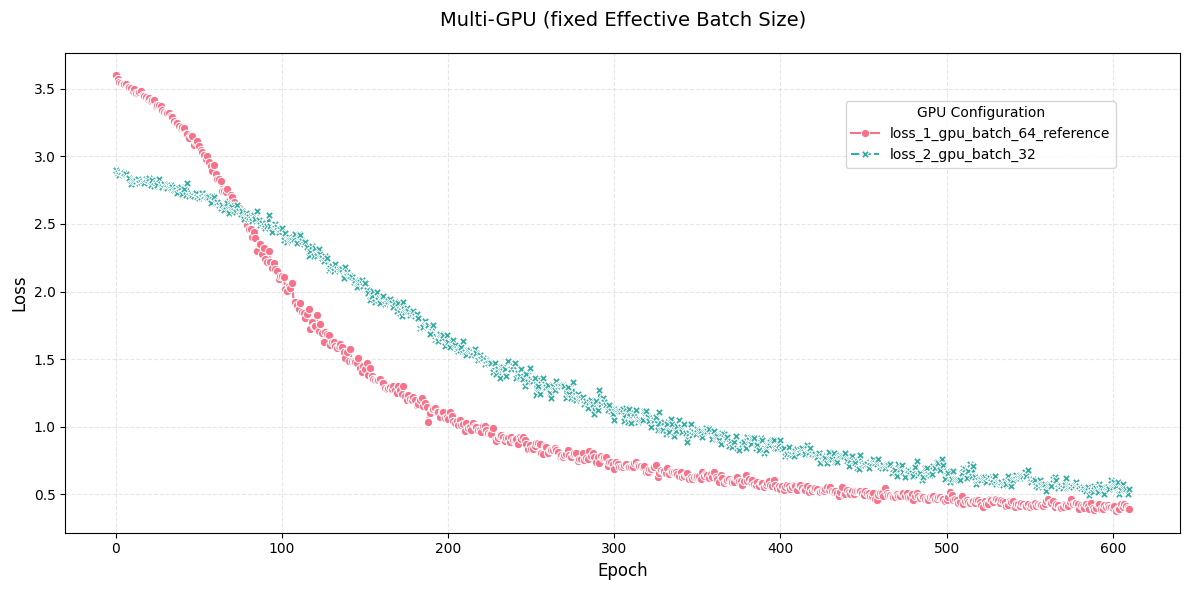

In [33]:
one_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/updated_exp/MOCOP1-149__training_train_morphological_loss.csv").iloc[:,-1]
two_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/updated_exp/MOCOP1-153__training_train_morphological_loss.csv").iloc[:,-1]
#three_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-140__training_train_loss.csv").iloc[:,-1]
#four_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-142__training_train_loss.csv").iloc[:,-1]

complete_data = pd.DataFrame({
            "loss_1_gpu_batch_64_reference":one_gpu,
            "loss_2_gpu_batch_32":two_gpu,
            #"loss_gpu_4_lr_0.004":three_gpu,
            #"loss_gpu_8_lr_0.008":four_gpu
            })
complete_data.index = complete_data.index.set_names(['epoch'])
complete_data = complete_data.reset_index()
complete_data.dropna(inplace = True)

# Melt the dataframe for easier plotting
melted_data = complete_data.melt(id_vars=['epoch'], 
                                var_name='GPU Config', 
                                value_name='Loss')

# Create the plot
plt.figure(figsize=(12, 6))

# Create line plot with custom styling
sns.lineplot(data=melted_data,
            x='epoch',
            y='Loss',
            hue='GPU Config',
            style='GPU Config',  # Different line styles for each GPU
            markers=True,        # Add markers
            dashes=True,         # Use different dash patterns
            palette='husl')      # Color palette

# Customize the plot
plt.title('Multi-GPU (fixed Effective Batch Size)', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Format legend
plt.legend(title='GPU Configuration', 
          bbox_to_anchor=(0.7, 0.9), 
          loc='upper left',
          borderaxespad=0)

# Add grid
plt.grid(True, linestyle='--', alpha=0.3)

# Tight layout
plt.tight_layout()


plt.savefig('/scratch/work/masooda1/mocop/junk/Multi_GPU_Fix_Effective_Batch_size_loss.png', dpi=300, bbox_inches='tight')

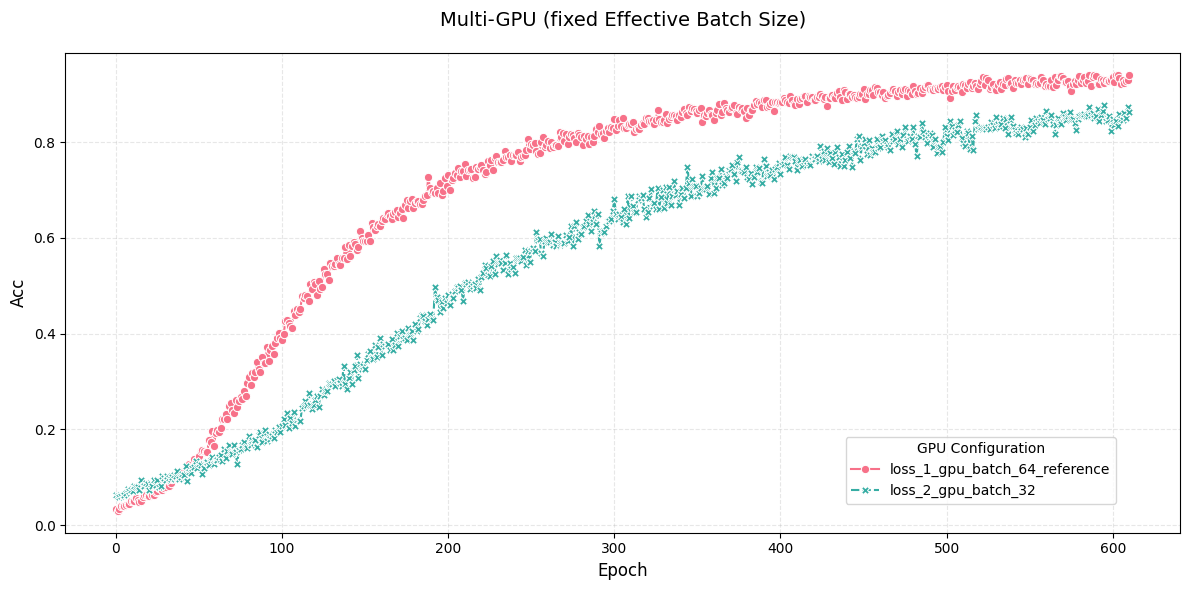

In [35]:
one_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/updated_exp/MOCOP1-149__training_train_acc.csv").iloc[:,-1]
two_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/updated_exp/MOCOP1-153__training_train_acc.csv").iloc[:,-1]
#three_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-140__training_train_loss.csv").iloc[:,-1]
#four_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-142__training_train_loss.csv").iloc[:,-1]

complete_data = pd.DataFrame({
            "loss_1_gpu_batch_64_reference":one_gpu,
            "loss_2_gpu_batch_32":two_gpu,
            #"loss_gpu_4_lr_0.004":three_gpu,
            #"loss_gpu_8_lr_0.008":four_gpu
            })
complete_data.index = complete_data.index.set_names(['epoch'])
complete_data = complete_data.reset_index()
complete_data.dropna(inplace = True)

# Melt the dataframe for easier plotting
melted_data = complete_data.melt(id_vars=['epoch'], 
                                var_name='GPU Config', 
                                value_name='Loss')

# Create the plot
plt.figure(figsize=(12, 6))

# Create line plot with custom styling
sns.lineplot(data=melted_data,
            x='epoch',
            y='Loss',
            hue='GPU Config',
            style='GPU Config',  # Different line styles for each GPU
            markers=True,        # Add markers
            dashes=True,         # Use different dash patterns
            palette='husl')      # Color palette

# Customize the plot
plt.title('Multi-GPU (fixed Effective Batch Size)', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Acc', fontsize=12)

# Format legend
plt.legend(title='GPU Configuration', 
          bbox_to_anchor=(0.7, 0.2), 
          loc='upper left',
          borderaxespad=0)

# Add grid
plt.grid(True, linestyle='--', alpha=0.3)

# Tight layout
plt.tight_layout()


plt.savefig('/scratch/work/masooda1/mocop/junk/Multi_GPU_Fix_Effective_Batch_Size_acc.png', dpi=300, bbox_inches='tight')

# Scaled LR

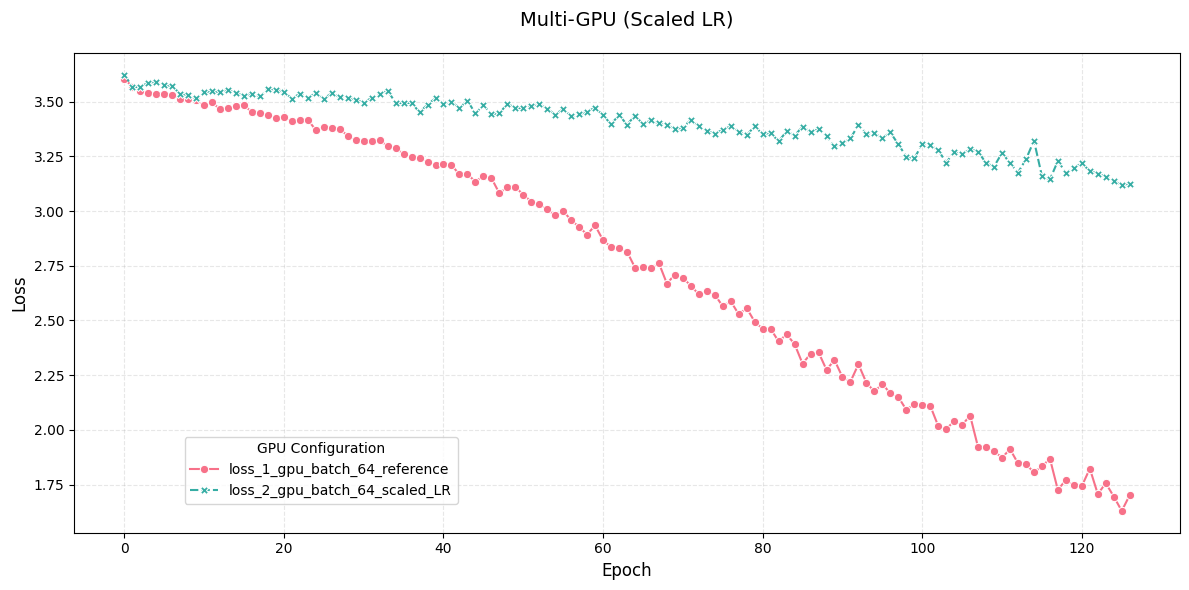

In [44]:
one_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/updated_exp/MOCOP1-149__training_train_morphological_loss.csv").iloc[:,-1]
two_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/updated_exp/MOCOP1-159__training_train_morphological_loss.csv").iloc[:,-1]
#three_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-140__training_train_loss.csv").iloc[:,-1]
#four_gpu = pd.read_csv("/scratch/work/masooda1/mocop/junk/MOCOP1-142__training_train_loss.csv").iloc[:,-1]

complete_data = pd.DataFrame({
            "loss_1_gpu_batch_64_reference":one_gpu,
            "loss_2_gpu_batch_64_scaled_LR":two_gpu,
            #"loss_gpu_4_lr_0.004":three_gpu,
            #"loss_gpu_8_lr_0.008":four_gpu
            })
complete_data.index = complete_data.index.set_names(['epoch'])
complete_data = complete_data.reset_index()
complete_data.dropna(inplace = True)

# Melt the dataframe for easier plotting
melted_data = complete_data.melt(id_vars=['epoch'], 
                                var_name='GPU Config', 
                                value_name='Loss')

# Create the plot
plt.figure(figsize=(12, 6))

# Create line plot with custom styling
sns.lineplot(data=melted_data,
            x='epoch',
            y='Loss',
            hue='GPU Config',
            style='GPU Config',  # Different line styles for each GPU
            markers=True,        # Add markers
            dashes=True,         # Use different dash patterns
            palette='husl')      # Color palette

# Customize the plot
plt.title('Multi-GPU (Scaled LR)', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Format legend
plt.legend(title='GPU Configuration', 
          bbox_to_anchor=(0.1, 0.2), 
          loc='upper left',
          borderaxespad=0)

# Add grid
plt.grid(True, linestyle='--', alpha=0.3)

# Tight layout
plt.tight_layout()


plt.savefig('/scratch/work/masooda1/mocop/junk/Multi_GPU_No_Schedular_Scaled_LR.png', dpi=300, bbox_inches='tight')